In [1]:
import numpy as np

In [13]:
#Intalizating weight and bias 
def intialize_weights(n_features):
    weights = np.zeros(n_features) 
    bias = 0 
    return weights, bias 

In [14]:
#Defining Activation Function 
def step_function(z):
    return 1 if z>=0 else 0 
    

In [15]:
#Computing weighted sum and applying activation function
def predict(x,weights,bias):
    z = np.dot(x,weights) + bias 
    return step_function(z)

In [16]:
#Upating weights and bias by using perceptron rule
def update_weights(weights, bias, xi, target, prediction, learning_rate):
    error = target - prediction 
    weights += learning_rate * error * xi 
    bias += learning_rate * error 
    return weights, bias

In [21]:
#Defining traininga rule 
def train_perceptron(X,y, learning_rate = 0.1 , epochs = 10):
    n_samples, n_features = X.shape 
    weights, bias = intialize_weights(n_features) 
    for epoch in range(epochs):
        for xi, target in zip(X,y):
            prediction = predict(xi,weights, bias) 
            weights, bias = update_weights(weights, bias, xi, target, prediction, learning_rate) 
    return weights, bias

In [25]:
#Final prediction function 
def predict_all(X, weights, bias):
    return [predict(x,weights,bias) for x in X]

In [26]:
#Preparing data to perform AND, OR operations using perceprtron 
#AND Gate
x_and = np.array([[0,0], [0,1], [1,0], [1,1] ]) 
y_and = np.array([0,0,0,1]) 
#OR Gate
x_or = np.array([[0,0], [0,1], [1,0], [1,1]]) 
y_or= np.array([0,1,1,1])

In [34]:
#Training perceptron on AND
weights_and , bias_and = train_perceptron(x_and, y_and) 
predictions_and = predict_all(x_and, weights_and, bias_and)
#Training perceptron on OR 
weights_or, bias_or = train_perceptron(x_or,y_or) 
predictions_or = predict_all(x_or, weights_or, bias_or)

In [35]:
import matplotlib.pyplot as plt
def plot_decision_boundary(X, y, weights, bias, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.array([step_function(np.dot(x, weights) + bias) for x in grid])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    class_0 = X[y == 0]
    class_1 = X[y == 1]
    plt.scatter(class_0[:, 0], class_0[:, 1], color='blue', edgecolors='k', label='0')
    plt.scatter(class_1[:, 0], class_1[:, 1], color='red', edgecolors='k', label='1')
    plt.legend(title="Output Class", fontsize=8, title_fontsize=9)
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.grid(True)
    plt.show()

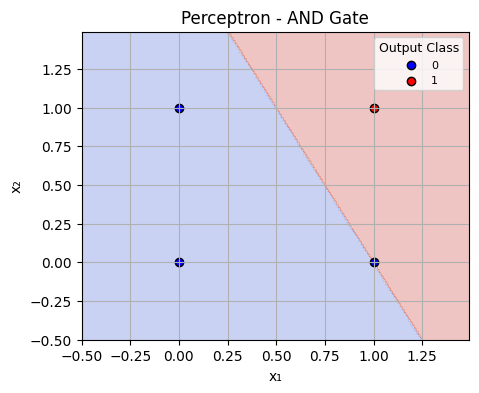

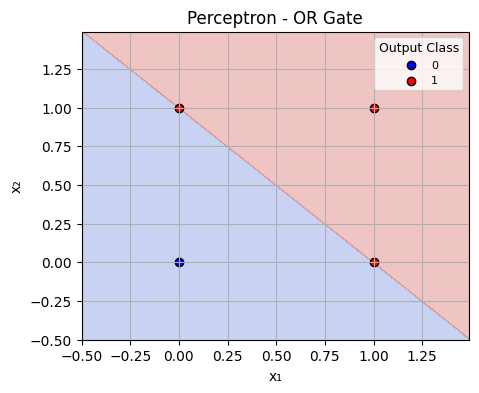

In [36]:
plot_decision_boundary(x_and, y_and, weights_and, bias_and, "Perceptron - AND Gate") 
plot_decision_boundary(x_or, y_or, weights_or, bias_or, "Perceptron - OR Gate") 


In [38]:
import pandas as pd 
from IPython.display import display 

df_and = pd.DataFrame({ 
    "x1": x_and[:,0], 
    "x2":x_and[:,1],
    "Actual": y_and, 
    "Predicted":predictions_and 
})
df_or = pd.DataFrame({ 
    "x1":x_or[:,0],
    "x2":x_or[:,1],
    "Actual":y_or,
    "Predicted":predictions_or
}) 
print("AND Gate prediction Results:") 
display(df_and) 
print("\nOR Gate Prediction results:") 
display(df_or)

AND Gate prediction Results:


,x1,x2,Actual,Predicted
0,0,0,0,0
1,0,1,0,0
2,1,0,0,0
3,1,1,1,1



OR Gate Prediction results:


,x1,x2,Actual,Predicted
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,1,1


In [39]:
#XOR Problem
x_xor = np.array([[0,0], [0,1],[1,0], [1,1] ])
y_xor = np.array([0,1,1,0]) 
#Training Perceptron on XOR data 
weights_xor, bias_xor = train_perceptron(x_xor, y_xor) 
#Predict using trained perceptron 
predictions_xor = predict_all(x_xor,weights_xor, bias_xor)

In [41]:
df_xor = pd.DataFrame({ 
    "x1" : x_xor[:,0], 
    "x2": x_xor[:,1], 
    "Actual": y_xor, 
    "Predicted": predictions_xor 
}) 
print("\nXOR Gate Prediction Results") 
display(df_xor)


XOR Gate Prediction Results


,x1,x2,Actual,Predicted
0,0,0,0,1
1,0,1,1,1
2,1,0,1,0
3,1,1,0,0


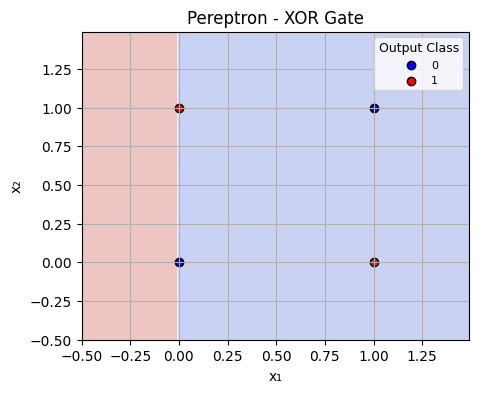

In [43]:
plot_decision_boundary(x_xor, y_xor, weights_xor, bias_xor, "Pereptron - XOR Gate")